# Graph Classification: GCN for Whole-Graph Topology Prediction (PyTorch Geometric)

The [previous GNN notebook](./gnn_node_classification.ipynb) did **node classification**: one big graph, predict a label for each node. This notebook does the other major GNN task, **graph classification**: *many small graphs*, predict one label for each *entire* graph.

Dataset: **synthetic random graphs**, generated on the fly with `networkx` from four classic random-graph "families":
- **Erdos-Renyi (ER)** — every pair of nodes connected independently at random. No preferred structure.
- **Barabasi-Albert (BA)** — "rich get richer" preferential attachment. Scale-free: a few high-degree hubs.
- **Watts-Strogatz (WS)** — small-world. Starts as a ring lattice, then randomly rewires a few edges.
- **Random Regular (RR)** — every node has exactly the same degree. Very uniform structure.

The task: given only the graph's *structure* (no node features carry any identity — every node starts with the same constant feature vector, see Section 3), predict which of the 4 families generated it. This forces the GNN to learn purely from connectivity patterns via message passing, which is exactly what makes it a clean GNN benchmark (a model that only looked at node features individually, ignoring edges, could not do better than random guessing here).

Same overall pipeline as the other notebooks:
1. Get the data (generate synthetic graphs)
2. Profile the data
3. Prepare the graphs (features, labels)
4. Split into train / validation / test
5. Build the model: GCNConv layers -> global pooling -> classifier head
6. Loss function & optimizer
7. Train, tracking train vs. validation loss/accuracy each epoch
8. Final evaluation on the held-out test set
9. Inference on a brand-new graph
10. Save the model

**Key difference from node classification:** there, one graph, mini-batching didn't make sense, so we did full-batch training over the single graph. Here there are *many independent graphs* of *different sizes*, so `DataLoader` mini-batching comes back — PyTorch Geometric batches variable-sized graphs by stacking them block-diagonally into one big disconnected graph, and a `global_mean_pool` collapses each graph's nodes back down to one vector per graph before the final classifier. This is the direct graph-level analogue of the CNN's `AdaptiveAvgPool2d -> Linear` head.


## 0. Install & Import Libraries

In [1]:
# !pip install torch torch_geometric networkx scikit-learn matplotlib --quiet

import random
from tqdm.auto import tqdm
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool
from torch_geometric.utils import from_networkx

from sklearn.model_selection import train_test_split

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


## 1. Get the Data

No external download here (unlike Cora) — we generate the dataset ourselves, procedurally, with random size and random generator parameters for every graph. That's a nice property for practice: you can make the dataset as big or as hard as you like just by changing the ranges below.


In [2]:
FAMILY_NAMES = ["Erdos-Renyi", "Barabasi-Albert", "Watts-Strogatz", "Random-Regular"]
NUM_GRAPHS_PER_CLASS = 300
MIN_NODES, MAX_NODES = 20, 60


def make_graph(family_idx, rng):
    n = rng.randint(MIN_NODES, MAX_NODES)

    if family_idx == 0:  # Erdos-Renyi
        p = rng.uniform(0.08, 0.20)
        g = nx.erdos_renyi_graph(n, p, seed=rng.randint(0, 10**6))
    elif family_idx == 1:  # Barabasi-Albert
        m = rng.randint(1, 4)
        g = nx.barabasi_albert_graph(n, m, seed=rng.randint(0, 10**6))
    elif family_idx == 2:  # Watts-Strogatz
        k = rng.choice([4, 6, 8])
        p = rng.uniform(0.05, 0.3)
        g = nx.watts_strogatz_graph(n, k, p, seed=rng.randint(0, 10**6))
    else:  # Random Regular
        d = rng.choice([3, 4, 5, 6])
        if (n * d) % 2 != 0:  # n*d must be even for a regular graph to exist
            n += 1
        g = nx.random_regular_graph(d, n, seed=rng.randint(0, 10**6))

    return g


rng = random.Random(SEED)
graphs, graph_labels = [], []
for family_idx in range(len(FAMILY_NAMES)):
    for _ in range(NUM_GRAPHS_PER_CLASS):
        graphs.append(make_graph(family_idx, rng))
        graph_labels.append(family_idx)

print(f"Generated {len(graphs)} graphs across {len(FAMILY_NAMES)} families "
      f"({NUM_GRAPHS_PER_CLASS} each).")


Generated 1200 graphs across 4 families (300 each).


## 2. Randomly Profile the Data

Same purpose as always: sanity-check sizes, class balance, and what these graphs actually look like before building anything.


In [3]:
node_counts = [g.number_of_nodes() for g in graphs]
edge_counts = [g.number_of_edges() for g in graphs]

print("Graph size (nodes): min={}, mean={:.1f}, max={}".format(
    min(node_counts), np.mean(node_counts), max(node_counts)))
print("Graph size (edges): min={}, mean={:.1f}, max={}".format(
    min(edge_counts), np.mean(edge_counts), max(edge_counts)))

unique, counts = np.unique(graph_labels, return_counts=True)
print("\nClass distribution:")
for u, c in zip(unique, counts):
    print(f"  {FAMILY_NAMES[u]:16s}: {c}")


Graph size (nodes): min=20, mean=40.7, max=60
Graph size (edges): min=17, mean=106.6, max=322

Class distribution:
  Erdos-Renyi     : 300
  Barabasi-Albert : 300
  Watts-Strogatz  : 300
  Random-Regular  : 300


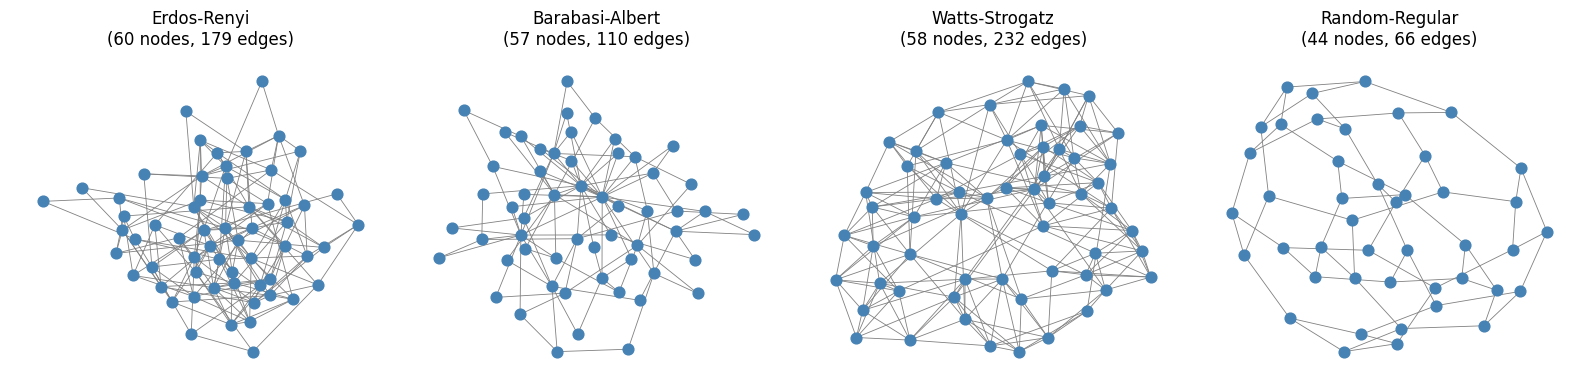

In [4]:
# Draw one example graph from each family, side by side.
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for family_idx, ax in enumerate(axes):
    example_idx = graph_labels.index(family_idx)
    g = graphs[example_idx]
    pos = nx.spring_layout(g, seed=SEED)
    nx.draw(
        g, pos, ax=ax, node_size=60, node_color="steelblue",
        edge_color="gray", width=0.6, with_labels=False,
    )
    ax.set_title(f"{FAMILY_NAMES[family_idx]}\n({g.number_of_nodes()} nodes, {g.number_of_edges()} edges)")

plt.tight_layout()
plt.show()


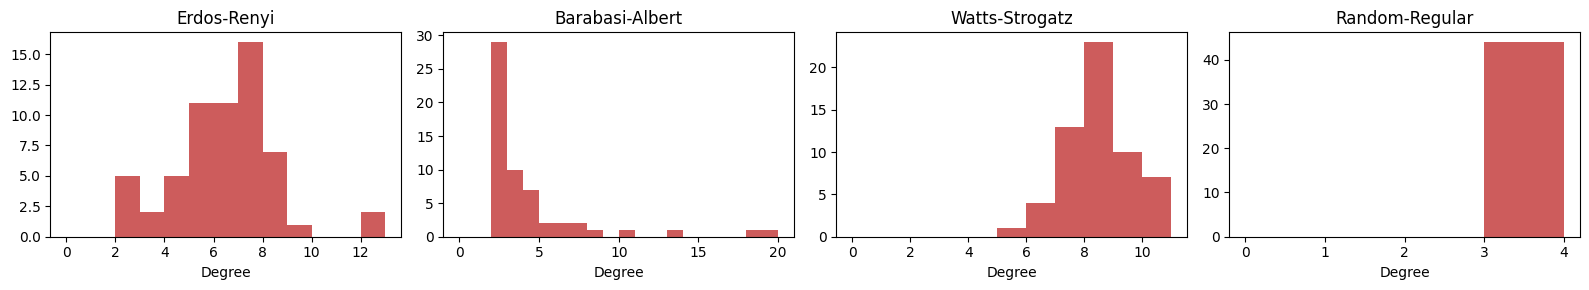

In [5]:
# Degree distribution is the key structural signature that distinguishes these families -
# e.g. Barabasi-Albert should show a heavy tail (hubs), Random-Regular should show a single spike.
fig, axes = plt.subplots(1, 4, figsize=(16, 3))
for family_idx, ax in enumerate(axes):
    example_idx = graph_labels.index(family_idx)
    degrees = [d for _, d in graphs[example_idx].degree()]
    ax.hist(degrees, bins=range(0, max(degrees) + 2), color="indianred")
    ax.set_title(FAMILY_NAMES[family_idx])
    ax.set_xlabel("Degree")
plt.tight_layout()
plt.show()


## 3. Prepare the Graphs

Each `networkx` graph gets converted to a PyG `Data` object with:
- `x`: node features. Deliberately set to a **constant** `[1.0]` per node (no identity, no degree, nothing informative on its own) — this is what forces the model to rely entirely on graph structure via message passing to solve the task, rather than shortcutting through node-level statistics.
- `edge_index`: the graph's edges, in PyG's `(2, num_edges)` format.
- `y`: the graph-level label (which family generated it) — one label per *graph*, not per node.


In [6]:
def to_pyg_data(g, label):
    data = from_networkx(g)
    data.x = torch.ones((g.number_of_nodes(), 1), dtype=torch.float)  # constant feature
    data.y = torch.tensor([label], dtype=torch.long)
    return data


pyg_dataset = [to_pyg_data(g, y) for g, y in zip(graphs, graph_labels)]
print("Example graph object:", pyg_dataset[0])
print("Total graphs:", len(pyg_dataset))


Example graph object: Data(edge_index=[2, 358], num_nodes=60, x=[60, 1], y=[1])
Total graphs: 1200


## 4. Split into Train / Validation / Test

In [7]:
all_indices = np.arange(len(pyg_dataset))

train_idx, temp_idx = train_test_split(
    all_indices, test_size=0.4, stratify=graph_labels, random_state=SEED
)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.5,
    stratify=[graph_labels[i] for i in temp_idx], random_state=SEED
)

train_set = [pyg_dataset[i] for i in train_idx]
val_set = [pyg_dataset[i] for i in val_idx]
test_set = [pyg_dataset[i] for i in test_idx]

print(f"Train graphs: {len(train_set)}")
print(f"Val graphs:   {len(val_set)}")
print(f"Test graphs:  {len(test_set)}")


Train graphs: 720
Val graphs:   240
Test graphs:  240


In [8]:
BATCH_SIZE = 32

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

# Peek at how PyG batches variable-sized graphs: it concatenates all nodes from every
# graph in the batch into one big disconnected graph, and `batch` tracks which graph
# each node belongs to (needed by global_mean_pool below to un-mix them again).
sample_batch = next(iter(train_loader))
print(sample_batch)
print("batch vector (first 20 entries):", sample_batch.batch[:20])


DataBatch(edge_index=[2, 7060], num_nodes=1302, x=[1302, 1], y=[32], batch=[1302], ptr=[33])
batch vector (first 20 entries): tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])


## 5. Build the Model: GCN with Global Pooling

Same conv-then-pool-then-classify shape as the CNN:
- **`GCNConv` x3**: each layer lets every node exchange information with its direct neighbors; stacking 3 means each node's final representation reflects everything within 3 hops.
- **`global_mean_pool`**: averages *all node vectors belonging to the same graph* down to one fixed-size vector per graph — the direct graph-level analogue of `AdaptiveAvgPool2d` collapsing spatial dimensions in the CNN. This is what turns a variable-size, node-level representation into a single, fixed-length, graph-level one.
- **Classifier head**: `Dropout -> Linear`, mapping the pooled vector to `num_classes` logits — identical shape to the CNN's head.


In [9]:
class GCNGraphClassifier(nn.Module):
    def __init__(self, in_features, hidden_dim, num_classes, dropout=0.3):
        super().__init__()
        self.conv1 = GCNConv(in_features, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.conv3 = GCNConv(hidden_dim, hidden_dim)

        self.classifier_head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x, edge_index, batch):
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = F.relu(self.conv3(x, edge_index))

        graph_embedding = global_mean_pool(x, batch)  # (num_graphs_in_batch, hidden_dim)
        logits = self.classifier_head(graph_embedding)
        return logits


In [10]:
model = GCNGraphClassifier(
    in_features=1,
    hidden_dim=64,
    num_classes=len(FAMILY_NAMES),
    dropout=0.3,
).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params: {total_params:,}")
print(f"Trainable params: {trainable_params:,}")


Total params: 8,708
Trainable params: 8,708


## 6. Loss Function & Optimizer

Note the learning rate here (`7e-3`) is higher than you might default to, plus a touch of `weight_decay`. With a single constant input feature, early gradients are small and the model needs a few epochs of larger steps before the per-node signal (which starts out nearly identical for every node) differentiates enough for GCNConv's bias terms and later layers to pick up meaningful structure. Try `1e-3` yourself and watch training stay stuck near chance accuracy for far longer — a good illustration of how sensitive GNNs trained from uninformative constant features can be to the learning rate.


In [11]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=7e-3, weight_decay=1e-4)


## 7. Training Loop

`DataLoader` mini-batching is back, same look as the CNN's loop — the only difference is unpacking a PyG `Batch` object (`.x`, `.edge_index`, `.batch`, `.y`) instead of an `(image, label)` pair.


In [12]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(loader, desc="Training", leave=False)
    for batch in progress_bar:
        batch = batch.to(device)

        optimizer.zero_grad()
        logits = model(batch.x, batch.edge_index, batch.batch)
        loss = criterion(logits, batch.y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * batch.num_graphs
        preds = torch.argmax(logits, dim=1)
        correct += (preds == batch.y).sum().item()
        total += batch.num_graphs

        progress_bar.set_postfix(loss=loss.item(), acc=correct / total)

    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy


In [13]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(loader, desc="Evaluating", leave=False)
    for batch in progress_bar:
        batch = batch.to(device)

        logits = model(batch.x, batch.edge_index, batch.batch)
        loss = criterion(logits, batch.y)

        total_loss += loss.item() * batch.num_graphs
        preds = torch.argmax(logits, dim=1)
        correct += (preds == batch.y).sum().item()
        total += batch.num_graphs

        progress_bar.set_postfix(loss=loss.item(), acc=correct / total)

    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy


In [14]:
NUM_EPOCHS = 60

history = []

for epoch in tqdm(range(1, NUM_EPOCHS + 1), desc="Epochs"):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)   # validation, NOT test

    history.append({
        "epoch": epoch,
        "train_loss": train_loss, "train_acc": train_acc,
        "val_loss": val_loss, "val_acc": val_acc,
    })

    if epoch % 10 == 0 or epoch == 1:
        print(
            f"Epoch {epoch}/{NUM_EPOCHS} | "
            f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
        )


Epochs:   0%|          | 0/60 [00:00<?, ?it/s]

Training:   0%|          | 0/23 [00:00<?, ?it/s]

Training:   0%|          | 0/23 [00:00<?, ?it/s, acc=0.25, loss=1.39]

Training:   0%|          | 0/23 [00:00<?, ?it/s, acc=0.25, loss=1.37]

Training:   0%|          | 0/23 [00:00<?, ?it/s, acc=0.292, loss=1.39]

...

Evaluating:   0%|          | 0/8 [00:00<?, ?it/s, acc=0.955, loss=0.276]

Evaluating:   0%|          | 0/8 [00:00<?, ?it/s, acc=0.958, loss=0.0815]

Epochs: 100%|██████████| 60/60 [00:35<00:00,  1.67it/s]

Epochs: 100%|██████████| 60/60 [00:35<00:00,  1.70it/s]

Epoch 60/60 | Train Loss: 0.3137, Train Acc: 0.8750 | Val Loss: 0.1854, Val Acc: 0.9583


## 7a. Plot Training & Validation Curves

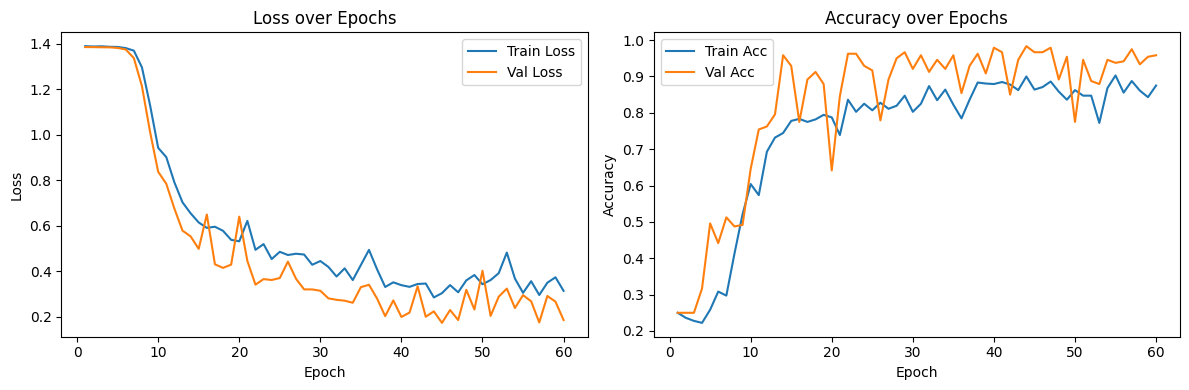

In [15]:
epochs = [h["epoch"] for h in history]
train_losses = [h["train_loss"] for h in history]
val_losses = [h["val_loss"] for h in history]
train_accs = [h["train_acc"] for h in history]
val_accs = [h["val_acc"] for h in history]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, train_losses, label="Train Loss")
axes[0].plot(epochs, val_losses, label="Val Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss over Epochs")
axes[0].legend()

axes[1].plot(epochs, train_accs, label="Train Acc")
axes[1].plot(epochs, val_accs, label="Val Acc")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy over Epochs")
axes[1].legend()

plt.tight_layout()
plt.show()


## 8. Final Evaluation on the Test Set

In [16]:
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}")


Evaluating:   0%|          | 0/8 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/8 [00:00<?, ?it/s, acc=0.875, loss=0.207]

Evaluating:   0%|          | 0/8 [00:00<?, ?it/s, acc=0.938, loss=0.128]

Evaluating:   0%|          | 0/8 [00:00<?, ?it/s, acc=0.948, loss=0.171]

Evaluating:   0%|          | 0/8 [00:00<?, ?it/s, acc=0.953, loss=0.157]

Evaluating:   0%|          | 0/8 [00:00<?, ?it/s, acc=0.944, loss=0.258]

Evaluating:   0%|          | 0/8 [00:00<?, ?it/s, acc=0.943, loss=0.28] 

Evaluating:   0%|          | 0/8 [00:00<?, ?it/s, acc=0.942, loss=0.215]

Evaluating:   0%|          | 0/8 [00:00<?, ?it/s, acc=0.946, loss=0.157]

Test Loss: 0.1992 | Test Accuracy: 0.9458


## 9. Inference on a Brand-New Graph

Generate a graph the model has never seen (fresh random seed, not from the train/val/test pools at all), predict its family, and check against the ground truth generator we used.


New graph: 37 nodes, 60 edges
True family:      Erdos-Renyi
Predicted family: Erdos-Renyi (confidence: 0.6883)


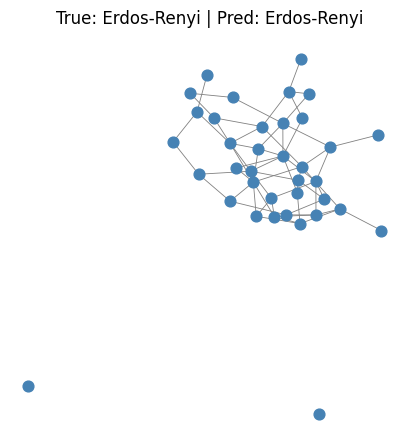

In [17]:
@torch.no_grad()
def predict_graph(model, pyg_data, family_names, device):
    model.eval()
    pyg_data = pyg_data.to(device)
    batch_vector = torch.zeros(pyg_data.num_nodes, dtype=torch.long, device=device)
    logits = model(pyg_data.x, pyg_data.edge_index, batch_vector)
    probs = F.softmax(logits, dim=1).squeeze(0)
    pred_idx = probs.argmax().item()
    return family_names[pred_idx], probs[pred_idx].item()


new_rng = random.Random(123)
true_family_idx = new_rng.randint(0, len(FAMILY_NAMES) - 1)
new_graph = make_graph(true_family_idx, new_rng)
new_data = to_pyg_data(new_graph, true_family_idx)

pred_label, confidence = predict_graph(model, new_data, FAMILY_NAMES, device)
true_label = FAMILY_NAMES[true_family_idx]

print(f"New graph: {new_graph.number_of_nodes()} nodes, {new_graph.number_of_edges()} edges")
print(f"True family:      {true_label}")
print(f"Predicted family: {pred_label} (confidence: {confidence:.4f})")

plt.figure(figsize=(4, 4))
pos = nx.spring_layout(new_graph, seed=SEED)
nx.draw(new_graph, pos, node_size=60, node_color="steelblue", edge_color="gray", width=0.6)
plt.title(f"True: {true_label} | Pred: {pred_label}")
plt.show()


## 10. Save the Model (optional)

In [18]:
torch.save(model.state_dict(), "gcn_graph_classifier.pt")
print("Model saved to gcn_graph_classifier.pt")

# To reload later:
# model = GCNGraphClassifier(in_features=1, hidden_dim=64, num_classes=len(FAMILY_NAMES), dropout=0.3)
# model.load_state_dict(torch.load("gcn_graph_classifier.pt", map_location=device))
# model.to(device)


Model saved to gcn_graph_classifier.pt
